Saving GraphiteExport.csv to GraphiteExport.csv
Epoch 1/80


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.7126
Epoch 2/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5621
Epoch 3/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4801
Epoch 4/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4591
Epoch 5/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4981
Epoch 6/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4974
Epoch 7/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5184
Epoch 8/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5472
Epoch 9/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4963
Epoch 10/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4658
Epoch 11/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5664
Epoch 12/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4448
Epoch 13/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4393
Epoch 14/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3856
Epoch 15/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4909
Epoch 16/80
11/11 ━━━━━━━━━━

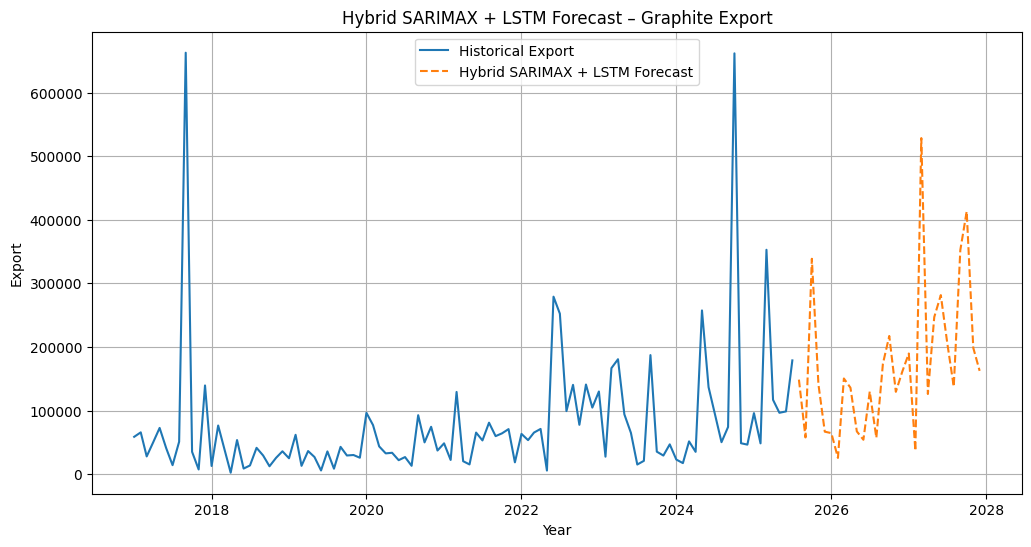

,Year,Forecast_Export
0,2025-08-01,148569.769596
1,2025-09-01,57711.195939
2,2025-10-01,338593.397978
3,2025-11-01,141138.045324
4,2025-12-01,66756.455614
5,2026-01-01,64452.517809
6,2026-02-01,25539.624896
7,2026-03-01,150369.982376
8,2026-04-01,135902.107491
9,2026-05-01,67215.505391


In [ ]:
# ==========================================================
# HYBRID SARIMAX + LSTM FORECAST – EXPORT TILL 2027
# ==========================================================

!pip install tensorflow pandas numpy matplotlib scikit-learn statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------------------------
# 1. Upload CSV
# -------------------------
uploaded = files.upload()
file = list(uploaded.keys())[0]

df = pd.read_csv(file)

# -------------------------
# 2. Clean & sort
# -------------------------
df.columns = df.columns.str.lower()
df['year'] = pd.to_datetime(df['year'], errors='coerce')
df = df.sort_values('year').reset_index(drop=True)

export_df = df[['year', 'export']].dropna()
y = export_df['export'].values.astype(float)

# -------------------------
# 3. Log transform (stability)
# -------------------------
y_log = np.log1p(y)

# -------------------------
# 4. SARIMAX (STRUCTURE)
# -------------------------
sarimax = SARIMAX(
    y_log,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax.fit(disp=False)

sarimax_fitted = sarimax_fit.fittedvalues

# -------------------------
# 5. Residuals
# -------------------------
residuals = y_log[1:] - sarimax_fitted[1:]

# -------------------------
# 6. Scale residuals
# -------------------------
scaler = StandardScaler()
res_scaled = scaler.fit_transform(residuals.reshape(-1,1))

# -------------------------
# 7. Residual sequences
# -------------------------
WINDOW = 18
X, y_res = [], []

for i in range(len(res_scaled) - WINDOW):
    X.append(res_scaled[i:i+WINDOW])
    y_res.append(res_scaled[i+WINDOW])

X = np.array(X)
y_res = np.array(y_res)

# -------------------------
# 8. LSTM on residuals
# -------------------------
model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(WINDOW,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(
    X, y_res,
    epochs=80,
    batch_size=8,
    verbose=1
)

# -------------------------
# 9. Forecast till 2027
# -------------------------
last_date = export_df['year'].iloc[-1]

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    end='2027-12-01',
    freq='MS'
)

steps = len(future_dates)

# SARIMAX forecast
sarimax_forecast = sarimax_fit.forecast(steps)

# LSTM residual forecast (recursive)
current_window = res_scaled[-WINDOW:].copy()
future_res_scaled = []

for _ in range(steps):
    pred = model.predict(current_window.reshape(1, WINDOW, 1), verbose=0)
    future_res_scaled.append(pred[0,0])
    current_window = np.vstack([current_window[1:], pred])

future_residuals = scaler.inverse_transform(
    np.array(future_res_scaled).reshape(-1,1)
).flatten()

# -------------------------
# 10. Combine forecasts
# -------------------------
future_log = sarimax_forecast + future_residuals
future_export = np.expm1(future_log)

# -------------------------
# 11. Plot
# -------------------------
plt.figure(figsize=(12,6))
plt.plot(export_df['year'], y, label='Historical Export')
plt.plot(future_dates, future_export, '--', label='Hybrid SARIMAX + LSTM Forecast')
plt.title('Hybrid SARIMAX + LSTM Forecast – Graphite Export')
plt.xlabel('Year')
plt.ylabel('Export')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# 12. Forecast table
# -------------------------
forecast_df = pd.DataFrame({
    'Year': future_dates,
    'Forecast_Export': future_export
})

forecast_df


Saving GraphiteExport.csv to GraphiteExport (2).csv
Epoch 1/80


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5576
Epoch 2/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5138
Epoch 3/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4265
Epoch 4/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4776
Epoch 5/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4799
Epoch 6/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4187
Epoch 7/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5712
Epoch 8/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4752
Epoch 9/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5378
Epoch 10/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4458
Epoch 11/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4003
Epoch 12/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5195
Epoch 13/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4979
Epoch 14/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4690
Epoch 15/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4857
Epoch 16/80
11/11 ━━━━

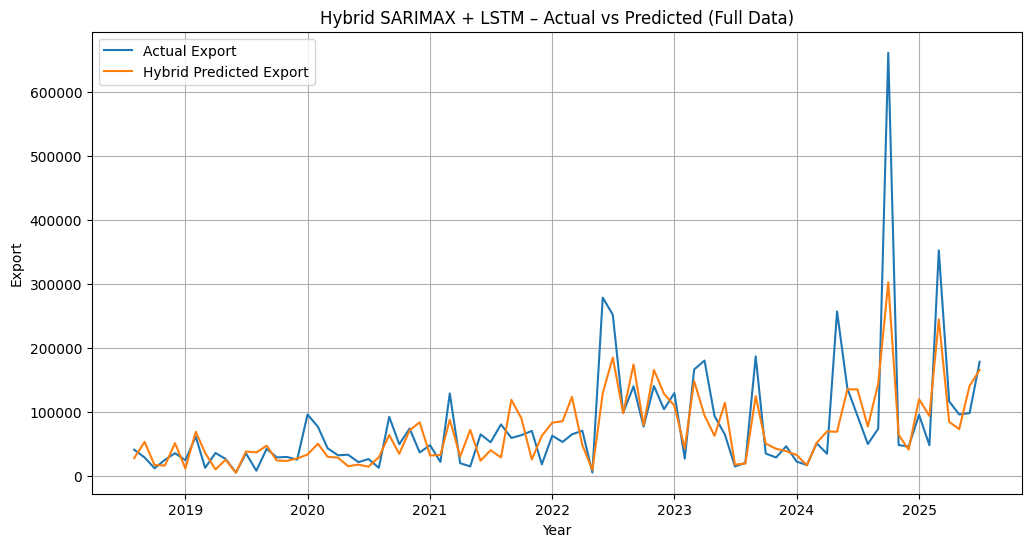

In [ ]:
# ==========================================================
# HYBRID SARIMAX + LSTM – ACTUAL vs PREDICTED (FULL DATA)
# ==========================================================

!pip install tensorflow pandas numpy matplotlib scikit-learn statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------------------------
# 1. Upload CSV
# -------------------------
uploaded = files.upload()
file = list(uploaded.keys())[0]

df = pd.read_csv(file)

# -------------------------
# 2. Clean & sort (AS-IS)
# -------------------------
df.columns = df.columns.str.lower()
df['year'] = pd.to_datetime(df['year'], errors='coerce')
df = df.sort_values('year').reset_index(drop=True)

export_df = df[['year', 'export']].dropna()
years = export_df['year']
y_raw = export_df['export'].values.astype(float)

# -------------------------
# 3. Log transform
# -------------------------
y_log = np.log1p(y_raw)

# -------------------------
# 4. SARIMAX (structure model)
# -------------------------
sarimax = SARIMAX(
    y_log,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax.fit(disp=False)

# One-step-ahead in-sample prediction
sarimax_pred = sarimax_fit.get_prediction(
    start=1,
    end=len(y_log)-1
).predicted_mean

sarimax_pred = np.asarray(sarimax_pred)  # ✅ ensure numpy

# -------------------------
# 5. Residuals (FIXED)
# -------------------------
residuals = y_log[1:] - sarimax_pred

# -------------------------
# 6. Scale residuals
# -------------------------
scaler = StandardScaler()
res_scaled = scaler.fit_transform(residuals.reshape(-1,1))

# -------------------------
# 7. Residual sequences
# -------------------------
WINDOW = 18

X, y_res = [], []
for i in range(len(res_scaled) - WINDOW):
    X.append(res_scaled[i:i+WINDOW])
    y_res.append(res_scaled[i+WINDOW])

X = np.array(X)
y_res = np.array(y_res)

# -------------------------
# 8. LSTM on residuals
# -------------------------
model = Sequential([
    LSTM(64, input_shape=(WINDOW,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(
    X, y_res,
    epochs=80,
    batch_size=8,
    verbose=1
)

# -------------------------
# 9. Predict residuals
# -------------------------
res_pred_scaled = model.predict(X, verbose=0)
res_pred = scaler.inverse_transform(res_pred_scaled).flatten()

# -------------------------
# 10. Combine SARIMAX + LSTM
# -------------------------
start_idx = 1 + WINDOW

hybrid_log_pred = sarimax_pred[WINDOW:] + res_pred

actual_log = y_log[start_idx:]
actual = np.expm1(actual_log)
predicted = np.expm1(hybrid_log_pred)

plot_years = years.iloc[start_idx:]

# -------------------------
# 11. Metrics
# -------------------------
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = mean_absolute_percentage_error(actual, predicted) * 100

print(f"\nRMSE (full series): {rmse:.2f}")
print(f"MAPE (full series): {mape:.2f}%")

# -------------------------
# 12. Plot
# -------------------------
plt.figure(figsize=(12,6))
plt.plot(plot_years, actual, label='Actual Export')
plt.plot(plot_years, predicted, label='Hybrid Predicted Export')
plt.title('Hybrid SARIMAX + LSTM – Actual vs Predicted (Full Data)')
plt.xlabel('Year')
plt.ylabel('Export')
plt.legend()
plt.grid(True)
plt.show()


Saving GraphiteExport.csv to GraphiteExport (4).csv
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.5526
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.3527
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.4135
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.4361
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4495
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.3888
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.4626
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3568
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.3877
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.2913
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.3774
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3420
Epoch 13/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3061
Epoch 14/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3018
Epoch 15/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.4639
Epoch 16/50
11/

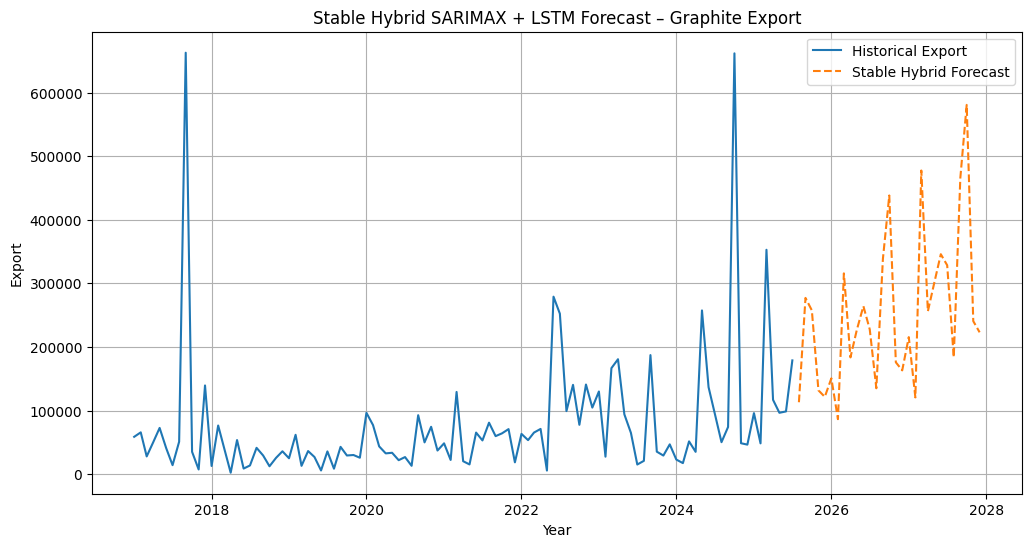

In [ ]:
# ==========================================================
# STABLE HYBRID SARIMAX + LSTM (RESIDUAL-DELTA, DAMPED)
# ==========================================================

!pip install tensorflow pandas numpy matplotlib scikit-learn statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------------------------
# 1. Upload CSV
# -------------------------
uploaded = files.upload()
file = list(uploaded.keys())[0]
df = pd.read_csv(file)

# -------------------------
# 2. Clean & sort
# -------------------------
df.columns = df.columns.str.lower()
df['year'] = pd.to_datetime(df['year'], errors='coerce')
df = df.sort_values('year').reset_index(drop=True)

export_df = df[['year', 'export']].dropna()
y = export_df['export'].values.astype(float)

# -------------------------
# 3. Log transform
# -------------------------
y_log = np.log1p(y)

# -------------------------
# 4. SARIMAX (trend + seasonality)
# -------------------------
sarimax = SARIMAX(
    y_log,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax.fit(disp=False)
sarimax_fitted = sarimax_fit.fittedvalues

# -------------------------
# 5. Residual DIFFERENCES (critical)
# -------------------------
residuals = y_log[1:] - sarimax_fitted[1:]
res_diff = np.diff(residuals)

# -------------------------
# 6. Scale residual deltas
# -------------------------
scaler = StandardScaler()
res_scaled = scaler.fit_transform(res_diff.reshape(-1,1))

# -------------------------
# 7. Sequences
# -------------------------
WINDOW = 18
X, y_res = [], []

for i in range(len(res_scaled) - WINDOW):
    X.append(res_scaled[i:i+WINDOW])
    y_res.append(res_scaled[i+WINDOW])

X = np.array(X)
y_res = np.array(y_res)

# -------------------------
# 8. LSTM (small & stable)
# -------------------------
model = Sequential([
    LSTM(32, input_shape=(WINDOW,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y_res, epochs=50, batch_size=8, verbose=1)

# -------------------------
# 9. Forecast till 2027
# -------------------------
last_date = export_df['year'].iloc[-1]

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    end='2027-12-01',
    freq='MS'
)

steps = len(future_dates)

# SARIMAX base forecast
sarimax_forecast = sarimax_fit.forecast(steps)

# LSTM residual-delta forecast (DAMPED)
current_window = res_scaled[-WINDOW:].copy()
future_res_deltas = []

DAMPING = 0.4   # <-- KEY stabilizer

for _ in range(steps):
    pred = model.predict(current_window.reshape(1, WINDOW, 1), verbose=0)[0,0]
    pred *= DAMPING
    future_res_deltas.append(pred)
    current_window = np.vstack([current_window[1:], [[pred]]])

future_res_deltas = scaler.inverse_transform(
    np.array(future_res_deltas).reshape(-1,1)
).flatten()

# -------------------------
# 10. Reconstruct residuals
# -------------------------
last_residual = residuals[-1]
future_residuals = np.cumsum(future_res_deltas) + last_residual

# -------------------------
# 11. Combine & invert log
# -------------------------
future_log = sarimax_forecast + future_residuals
future_export = np.expm1(future_log)

# -------------------------
# 12. Plot
# -------------------------
plt.figure(figsize=(12,6))
plt.plot(export_df['year'], y, label='Historical Export')
plt.plot(future_dates, future_export, '--', label='Stable Hybrid Forecast')
plt.title('Stable Hybrid SARIMAX + LSTM Forecast – Graphite Export')
plt.xlabel('Year')
plt.ylabel('Export')
plt.legend()
plt.grid(True)
plt.show()
